### Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_iris

from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

### Project Assigning/Information Gathering

In [ ]:
Client/Stakeholder         >> Person
Project                    >> Car (Service= Testing, Web Development, Games, Automation)
Company                    >> Car Company
POC(Proof of Concept)      >> Test Drive

POC >> Paid POC/Non-Paid
Duaration >> 1 week to 4 weeks, rarely (2-3 months)
POC started >> 23-11-24

Sensitive Data(Info):
    NDA(Non-Disclosure Agreement)

Data:
    Download >> Less Observations
    Access (SQL-Server) >> Limited Access

Problem Statement >> Solution
Output >> Deliverables

Client Meeting >> Create PPT/Deck/Excel
Requirements >> Set of features to use:
    1. Frequency of Customers
    2. Nearby Hotels
    3. Area measurements
    4. Locations
    5. Veg/Non-Veg
    6. Indian/Foreign
    7. Ambiance
    8. Price
    9. Type of Place
    10. Liqour

Approaches:
    ML(Regression, Classification, Segmentation)
    DL
    NLP
    TSA
    Chatbot
    Gen AI
    Without ML(Rule Based)

To discusss anything with Client side:
    POC/SPOC >>> Single Point of Contact

POC-Closure(Delivered) >> 15-12-2024

POC will be reviewed by Client

Project Kickoff >> 22-12-2024

### Problem Statement/Business Problem

In [ ]:
To predict SepalLengthCM values with the help of independent variables

Dependent Var >> SepalLengthCM
Indepedent Var >> SepatlWidthCM, PetalWidthCM, PetalLengthCM, Species

# Hypothesis(Assumptions) Generation

### Data Gathering

In [2]:
iris_data = load_iris()
print(dir(iris_data))

['DESCR', 'data', 'data_module', 'feature_names', 'filename', 'frame', 'target', 'target_names']


In [3]:
print(iris_data.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [4]:
iris_df = pd.DataFrame(iris_data.data, columns=iris_data.feature_names)
iris_df['Species'] = iris_data.target
iris_df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


### Exploratory Data Analysis

In [5]:
iris_df.shape

(150, 5)

In [6]:
iris_df.columns

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'Species'],
      dtype='object')

In [7]:
iris_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   Species            150 non-null    int32  
dtypes: float64(4), int32(1)
memory usage: 5.4 KB


In [8]:
iris_df.isna().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
Species              0
dtype: int64

In [9]:
iris_df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [10]:
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [5]:
iris_df.columns = ['SepalLengthCM','SepatlWidthCM', 'PetalLengthCM','PetalWidthCM', 'Species']
iris_df.head()

,SepalLengthCM,SepatlWidthCM,PetalLengthCM,PetalWidthCM,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [ ]:
3 types of EDA:
    1. Univariate >> Analysis of single variable
    2. Bivariate  >> Analyse 2 var at a time
    3. Multivariate >> Analyse multiple features at a time

Categorical:
    unique, nunique, valuecounts, piechart, countplot, bargraph

Numerical:
    nunique, kdeplot, histogram, boxplot, statistical values

#### 3.1 SepatlWidthCM

In [17]:
iris_df['SepatlWidthCM'].unique()

array([3.5, 3. , 3.2, 3.1, 3.6, 3.9, 3.4, 2.9, 3.7, 4. , 4.4, 3.8, 3.3,
       4.1, 4.2, 2.3, 2.8, 2.4, 2.7, 2. , 2.2, 2.5, 2.6])

In [18]:
iris_df['SepatlWidthCM'].nunique()

23

<Axes: xlabel='SepatlWidthCM', ylabel='Count'>

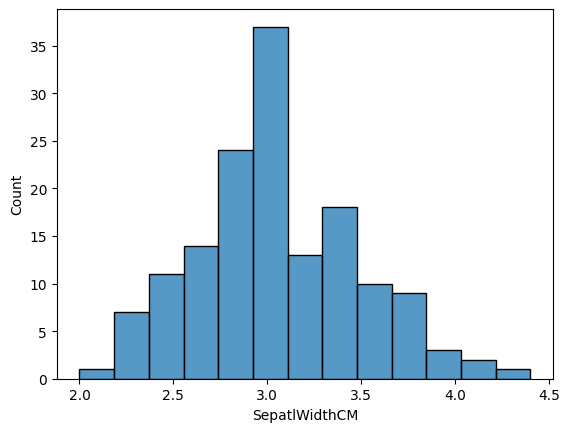

In [19]:
sns.histplot(iris_df['SepatlWidthCM'])

<Axes: xlabel='SepatlWidthCM', ylabel='Density'>

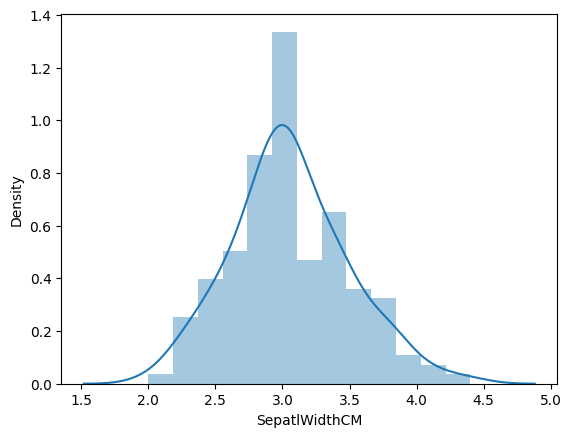

In [20]:
sns.distplot(iris_df['SepatlWidthCM'])

<Axes: xlabel='SepatlWidthCM', ylabel='Density'>

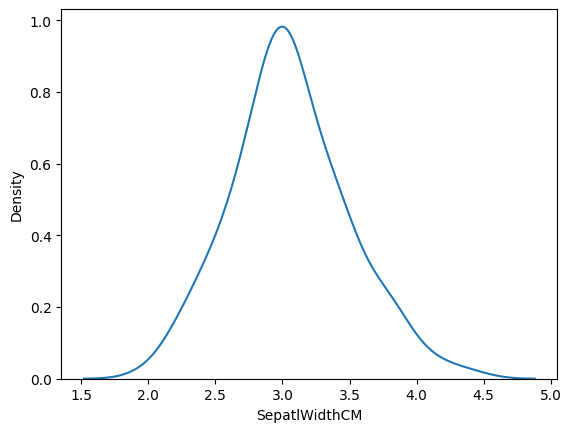

In [21]:
sns.kdeplot(iris_df['SepatlWidthCM'])

<Axes: xlabel='SepatlWidthCM', ylabel='count'>

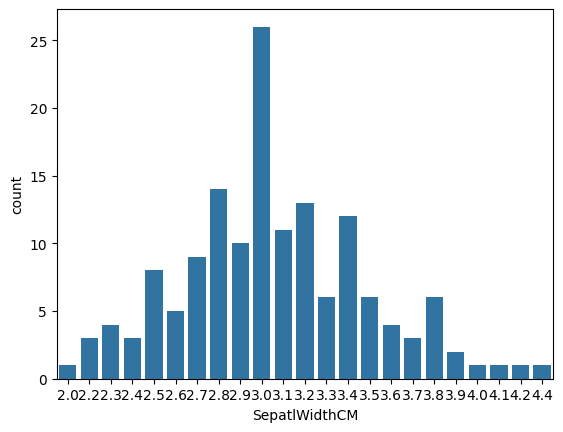

In [23]:
sns.countplot(x=iris_df['SepatlWidthCM'])

<Axes: ylabel='SepatlWidthCM'>

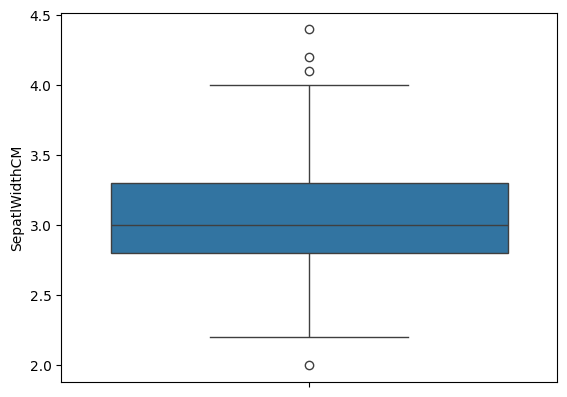

In [24]:
sns.boxplot(iris_df['SepatlWidthCM'])

##### Conclusion : Outliers need to be trated

#### 3.2 PetalLengthCM

In [25]:
iris_df['PetalLengthCM']

0      1.4
1      1.4
2      1.3
3      1.5
4      1.4
      ... 
145    5.2
146    5.0
147    5.2
148    5.4
149    5.1
Name: PetalLengthCM, Length: 150, dtype: float64

<Axes: xlabel='PetalLengthCM', ylabel='Density'>

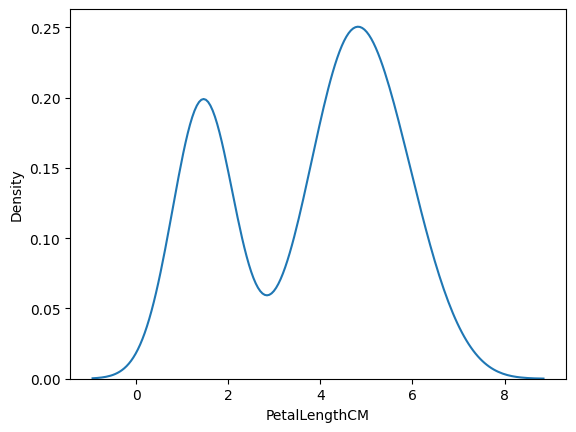

In [26]:
sns.kdeplot(iris_df['PetalLengthCM'])

<Axes: xlabel='PetalLengthCM', ylabel='Density'>

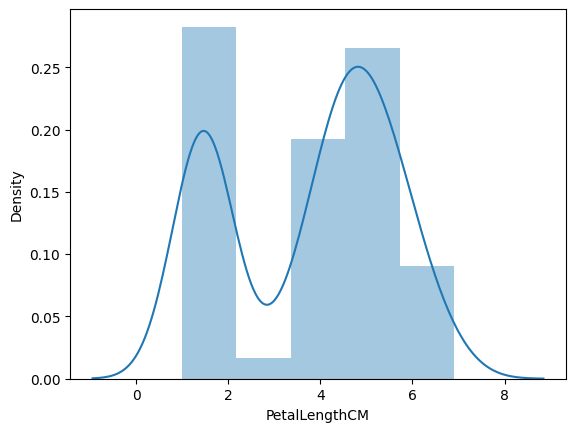

In [28]:
sns.distplot(iris_df['PetalLengthCM'])

<Axes: ylabel='PetalLengthCM'>

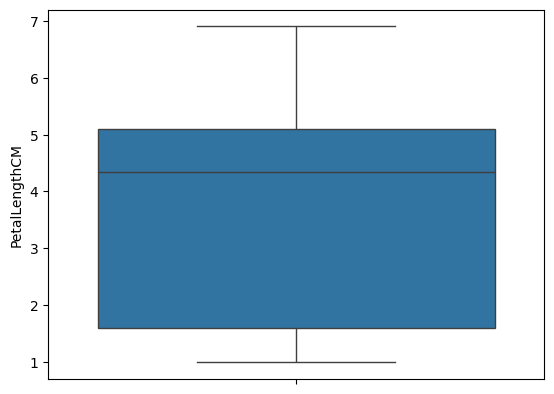

In [29]:
sns.boxplot(iris_df['PetalLengthCM'])

In [36]:
iris_df['PetalLengthCM'].skew()

-0.27488417975101276

##### Conclusion : This feature may require transformation

#### 3.3 PetalWidthCM

In [30]:
iris_df['PetalWidthCM']

0      0.2
1      0.2
2      0.2
3      0.2
4      0.2
      ... 
145    2.3
146    1.9
147    2.0
148    2.3
149    1.8
Name: PetalWidthCM, Length: 150, dtype: float64

<Axes: xlabel='PetalWidthCM', ylabel='Count'>

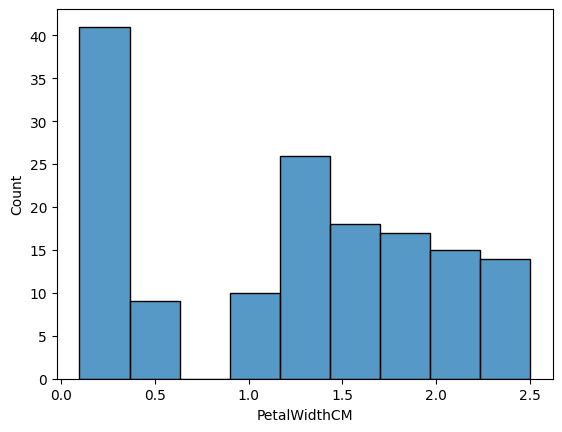

In [31]:
sns.histplot(iris_df['PetalWidthCM'])

<Axes: xlabel='PetalWidthCM', ylabel='Density'>

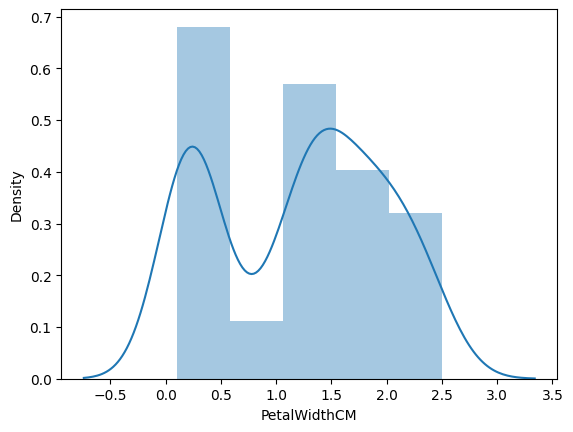

In [32]:
sns.distplot(iris_df['PetalWidthCM'])

<Axes: xlabel='PetalWidthCM', ylabel='Density'>

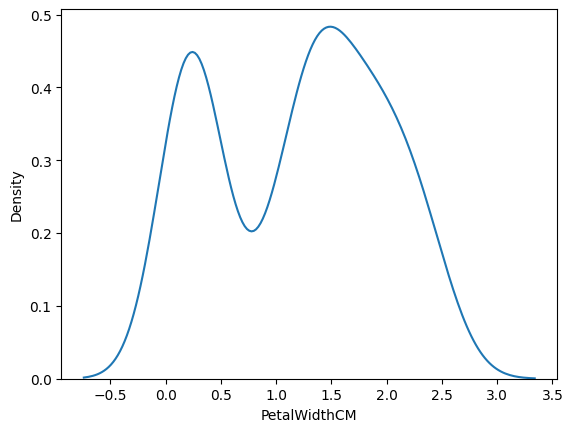

In [33]:
sns.kdeplot(iris_df['PetalWidthCM'])

<Axes: ylabel='PetalWidthCM'>

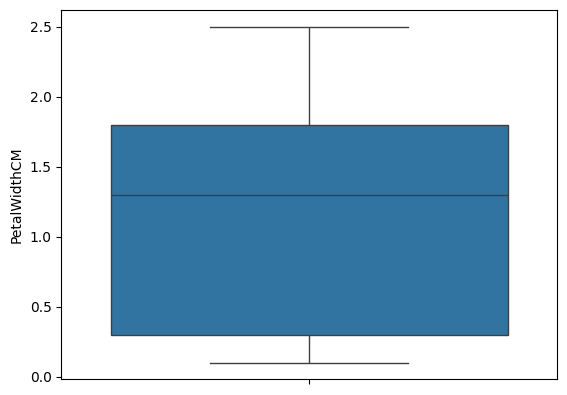

In [34]:
sns.boxplot(iris_df['PetalWidthCM'])

In [35]:
iris_df['PetalWidthCM'].skew()

-0.10296674764898116

##### Conclusion : This feature may require transformation

#### 3.4 Species

In [38]:
iris_df['Species'].unique()

array([0, 1, 2])

In [39]:
iris_df['Species'].nunique()

3

In [40]:
iris_df['Species'].value_counts()

Species
0    50
1    50
2    50
Name: count, dtype: int64

<Axes: xlabel='Species', ylabel='count'>

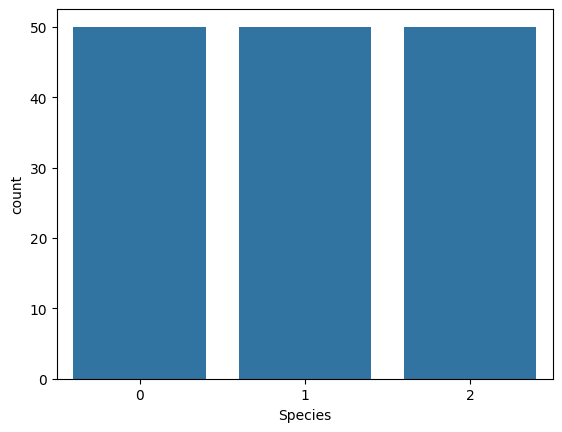

In [44]:
sns.countplot(x=iris_df['Species'], )

### Feature Engineering

#### Feature Selection

##### Linearity

In [45]:
iris_df.cov()     # Covariance Matrix

,SepalLengthCM,SepatlWidthCM,PetalLengthCM,PetalWidthCM,Species
SepalLengthCM,0.685694,-0.042434,1.274315,0.516271,0.530872
SepatlWidthCM,-0.042434,0.189979,-0.329656,-0.121639,-0.152349
PetalLengthCM,1.274315,-0.329656,3.116278,1.295609,1.372483
PetalWidthCM,0.516271,-0.121639,1.295609,0.581006,0.597315
Species,0.530872,-0.152349,1.372483,0.597315,0.671141


In [46]:
iris_df.std()

SepalLengthCM    0.828066
SepatlWidthCM    0.435866
PetalLengthCM    1.765298
PetalWidthCM     0.762238
Species          0.819232
dtype: float64

In [47]:
iris_df.var()

SepalLengthCM    0.685694
SepatlWidthCM    0.189979
PetalLengthCM    3.116278
PetalWidthCM     0.581006
Species          0.671141
dtype: float64

In [48]:
iris_df.corr()

,SepalLengthCM,SepatlWidthCM,PetalLengthCM,PetalWidthCM,Species
SepalLengthCM,1.000000,-0.117570,0.871754,0.817941,0.782561
SepatlWidthCM,-0.117570,1.000000,-0.428440,-0.366126,-0.426658
PetalLengthCM,0.871754,-0.428440,1.000000,0.962865,0.949035
PetalWidthCM,0.817941,-0.366126,0.962865,1.000000,0.956547
Species,0.782561,-0.426658,0.949035,0.956547,1.000000


<Axes: xlabel='SepalLengthCM', ylabel='SepalLengthCM'>

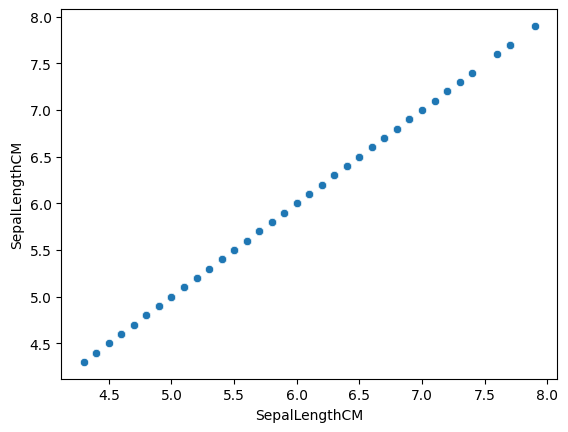

In [50]:
sns.scatterplot(x =iris_df['SepalLengthCM'], y =iris_df['SepalLengthCM'])

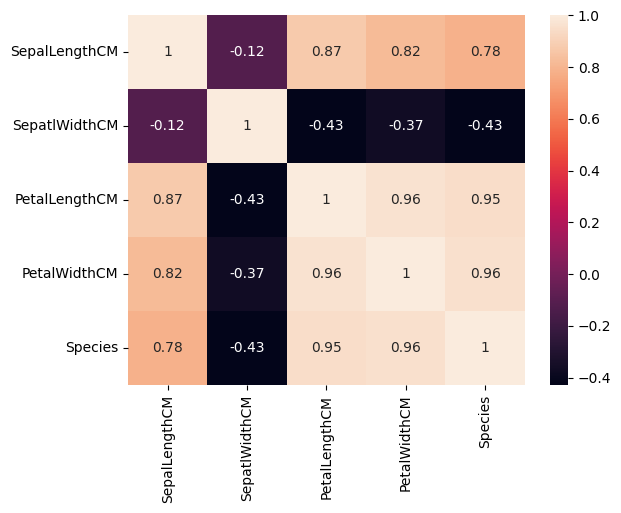

In [55]:
sns.heatmap(iris_df.corr(), annot=True)
plt.savefig('Correlation_matrix.jpg')

In [58]:
correlation = iris_df.corr().head(1)
correlation

,SepalLengthCM,SepatlWidthCM,PetalLengthCM,PetalWidthCM,Species
SepalLengthCM,1.0,-0.11757,0.871754,0.817941,0.782561


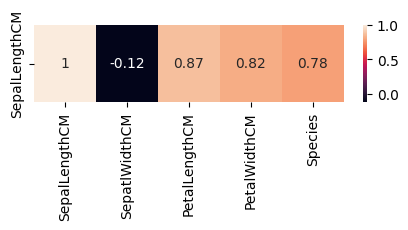

In [60]:
plt.figure(figsize=(5,1))
sns.heatmap(correlation, annot=True)
plt.savefig('Correlation_target.jpg')

<Axes: xlabel='PetalLengthCM', ylabel='SepalLengthCM'>

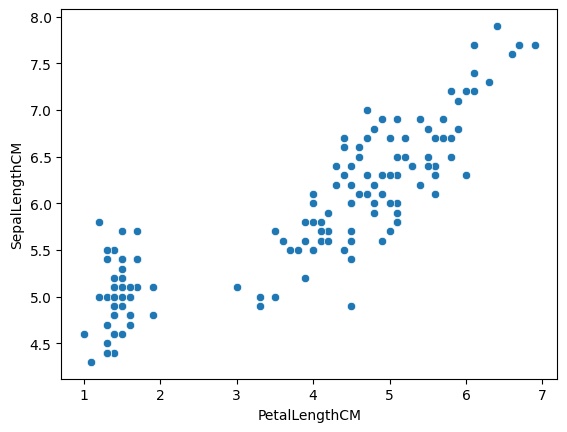

In [61]:
sns.scatterplot(y =iris_df['SepalLengthCM'], x =iris_df['PetalLengthCM'])

<Axes: xlabel='SepatlWidthCM', ylabel='SepalLengthCM'>

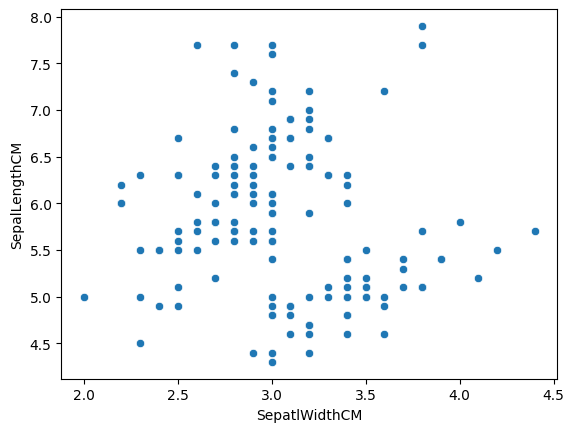

In [62]:
sns.scatterplot(y =iris_df['SepalLengthCM'], x =iris_df['SepatlWidthCM'])

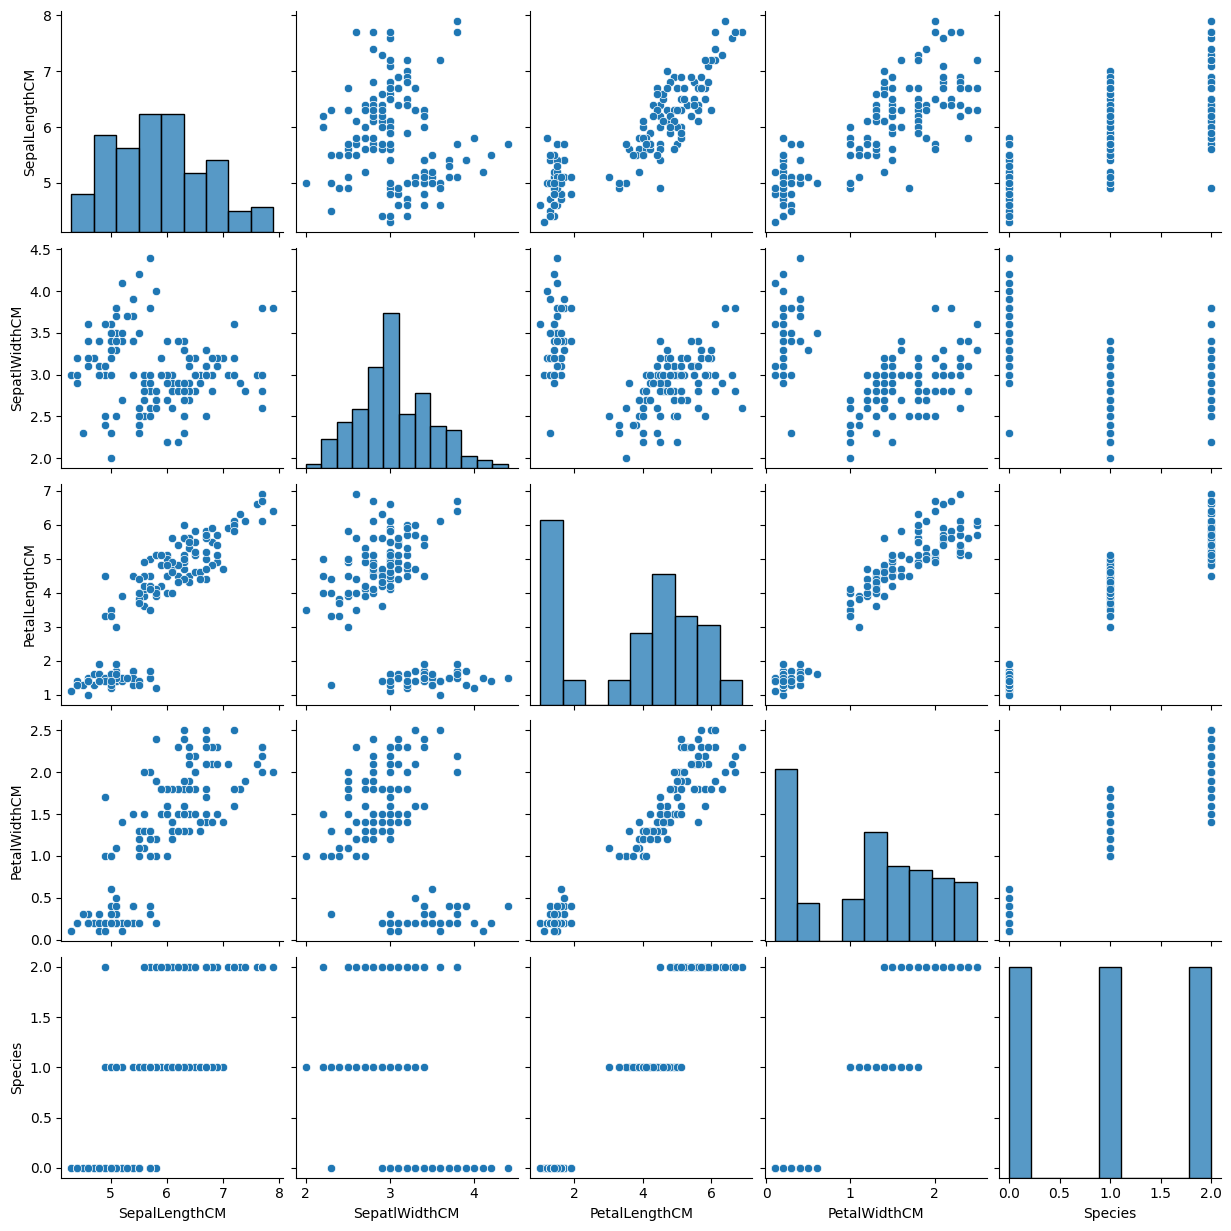

In [63]:
sns.pairplot(iris_df)

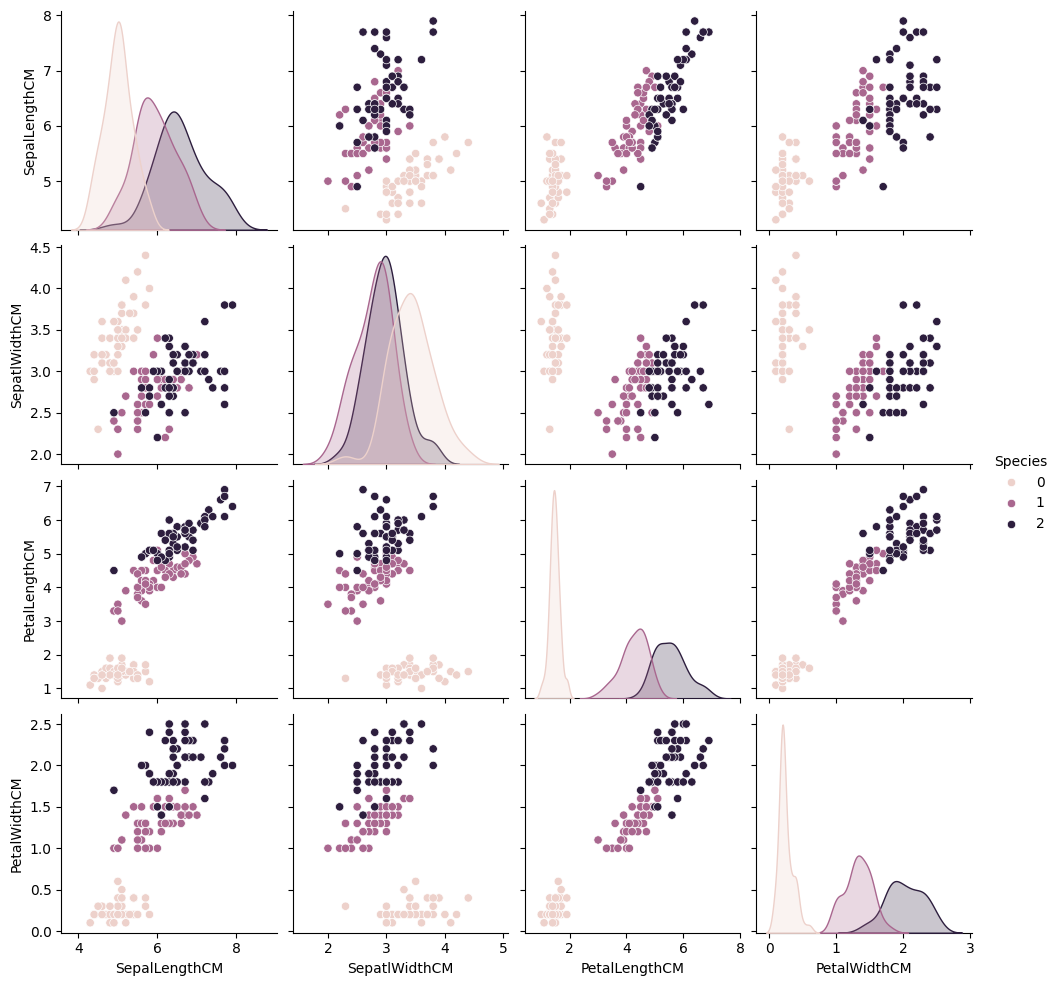

In [64]:
sns.pairplot(iris_df, hue = 'Species')

In [ ]:
https://plotly.com/python/3d-scatter-plots/

#### No Multicolinearity

In [ ]:
VIF >> Variance Inflation Factor

In [70]:
iris_df.columns

Index(['SepalLengthCM', 'SepatlWidthCM', 'PetalLengthCM', 'PetalWidthCM',
       'Species'],
      dtype='object')

In [75]:
for i in range(1, iris_df.shape[1]):
    vif = variance_inflation_factor(iris_df.values, i)
    print(f'VIF of {iris_df.columns[i]} is : {vif}')

VIF of SepatlWidthCM is : 96.46673090053491
VIF of PetalLengthCM is : 191.61705308519376
VIF of PetalWidthCM is : 71.03519530845257
VIF of Species is : 35.71225297716894


### Model Training/Building

In [6]:
x = iris_df.drop('SepalLengthCM', axis = 1)  # 2D
y = iris_df['SepalLengthCM']   # 1D

In [7]:
x.head()

,SepatlWidthCM,PetalLengthCM,PetalWidthCM,Species
0,3.5,1.4,0.2,0
1,3.0,1.4,0.2,0
2,3.2,1.3,0.2,0
3,3.1,1.5,0.2,0
4,3.6,1.4,0.2,0


In [8]:
y.head()

0    5.1
1    4.9
2    4.7
3    4.6
4    5.0
Name: SepalLengthCM, dtype: float64

### Splitting dataset into train and test

##### Train test split

In [9]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.20, random_state=2)
x_train

,SepatlWidthCM,PetalLengthCM,PetalWidthCM,Species
126,2.8,4.8,1.8,2
23,3.3,1.7,0.5,0
64,2.9,3.6,1.3,1
117,3.8,6.7,2.2,2
84,3.0,4.5,1.5,1
...,...,...,...,...
75,3.0,4.4,1.4,1
43,3.5,1.6,0.6,0
22,3.6,1.0,0.2,0
72,2.5,4.9,1.5,1


In [10]:
x_test.shape

(30, 4)

In [11]:
y_train.shape

(120,)

In [12]:
y_test.shape

(30,)

### Instantiation of Linear Regression Model

In [13]:
linear_reg = LinearRegression()
linear_reg

LinearRegression()

### Model Training

In [14]:
linear_reg.fit(x_train, y_train)  # Use to train the model, It learns parameters of instance

LinearRegression()

In [ ]:
y = m1x1 + m2mx2 + m3x3 + m4x4 + c

In [16]:
linear_reg.n_features_in_

4

In [17]:
linear_reg.coef_

array([ 0.67427277,  0.73517612, -0.38876303, -0.22592787])

In [18]:
linear_reg.intercept_

1.7161304636997787

In [19]:
x_test.head()

,SepatlWidthCM,PetalLengthCM,PetalWidthCM,Species
6,3.4,1.4,0.3,0
3,3.1,1.5,0.2,0
113,2.5,5.0,2.0,2
12,3.0,1.4,0.1,0
24,3.4,1.9,0.2,0


In [20]:
y_test.head()

6      4.6
3      4.6
113    5.7
12     4.8
24     4.8
Name: SepalLengthCM, dtype: float64

### Model Evaluation

In [21]:
y_pred = linear_reg.predict(x_test)
y_pred

array([4.92127555, 4.83138763, 5.8483112 , 4.72931905, 5.32773991,
       6.92909369, 4.83747797, 6.5142047 , 6.4528224 , 4.65156644,
       5.2359513 , 4.75177969, 4.67826207, 5.44008847, 6.46900171,
       6.17683197, 4.10605789, 6.0279414 , 6.70797119, 5.61119707,
       6.52800436, 6.10145901, 6.42422607, 5.89308685, 5.77041296,
       4.97233252, 4.75177969, 6.18968258, 5.51969642, 7.13323087])

In [22]:
y_pred[:5]  # Pred

array([4.92127555, 4.83138763, 5.8483112 , 4.72931905, 5.32773991])

In [23]:
y_test[:5] # Act

6      4.6
3      4.6
113    5.7
12     4.8
24     4.8
Name: SepalLengthCM, dtype: float64

In [24]:
residuals = y_test - y_pred
residuals

6     -0.321276
3     -0.231388
113   -0.148311
12     0.070681
24    -0.527740
129    0.270906
25     0.162522
108    0.185795
128   -0.052822
45     0.148434
48     0.064049
42    -0.351780
35     0.321738
5     -0.040088
85    -0.469002
54     0.323168
41     0.393942
96    -0.327941
144   -0.007971
89    -0.111197
77     0.171996
74     0.298541
115   -0.024226
94    -0.293087
87     0.529587
29    -0.272333
2     -0.051780
127   -0.089683
44    -0.419696
125    0.066769
Name: SepalLengthCM, dtype: float64

### Evaluation on Testing Data

In [25]:
mse = mean_squared_error(y_test, y_pred)
print('Mean Squared Error :', mse)

rmse = np.sqrt(mse)
print('Root Mean Squared Error :', rmse)

mae = mean_absolute_error(y_test, y_pred)
print('Mean Absolute Error :', mae)

r_square = r2_score(y_test, y_pred)
print('R-Squared Value :', r_square)

adj_r2 = 1 - (((1- r_square)*(y_test.shape[0] - 1))/ (y_test.shape[0] - x_test.shape[1] - 1))
print('Adj-R-Squared Value :', adj_r2)

Mean Squared Error : 0.07350315613968067
Root Mean Squared Error : 0.2711146549703292
Mean Absolute Error : 0.22494826893879435
R-Squared Value : 0.8982827349072627
Adj-R-Squared Value : 0.8820079724924248


In [26]:
r_square = linear_reg.score(x_test, y_test)
print('R-Squared Value :', r_square)

R-Squared Value : 0.8982827349072627


### Evaluation on Training Data

In [27]:
y_pred_train = linear_reg.predict(x_train)
y_pred_train

array([5.98131041, 4.9966485 , 5.58683573, 7.8969126 , 6.23816891,
       5.21768029, 6.4139461 , 6.35056282, 5.47634251, 6.20976357,
       6.17074163, 6.10145901, 6.86533174, 5.07834814, 5.10718708,
       6.59010197, 4.96015185, 6.27095488, 5.02757913, 5.10109674,
       4.95406152, 5.59735205, 6.63259823, 7.75411237, 5.18070469,
       6.53847532, 6.74075716, 7.32285307, 5.84041088, 4.50876621,
       4.90490524, 6.09555967, 5.88699651, 5.63365771, 6.87751241,
       5.98740075, 5.8134789 , 5.15819869, 6.18106696, 5.14601802,
       5.96860543, 5.71750065, 4.95377355, 5.4115375 , 5.43984586,
       6.01761607, 6.45263141, 7.30039243, 4.69044274, 6.54860966,
       5.26450227, 5.71141031, 6.71829652, 4.87026394, 5.02310153,
       4.83138763, 4.91518522, 5.2359513 , 6.51415934, 6.92852402,
       5.02943447, 5.54453671, 5.8871875 , 7.19594419, 5.52554414,
       7.20432347, 5.14577542, 6.36697849, 6.33248281, 4.98870283,
       6.89816306, 6.3367178 , 6.24259489, 4.62301547, 5.97707

In [28]:
mse = mean_squared_error(y_train, y_pred_train)
print('Mean Squared Error :', mse)

rmse = np.sqrt(mse)
print('Root Mean Squared Error :', rmse)

mae = mean_absolute_error(y_train, y_pred_train)
print('Mean Absolute Error :', mae)

r_square = r2_score(y_train, y_pred_train)
print('R-Squared Value :', r_square)

adj_r2 = 1 - (((1- r_square)*(y_train.shape[0] - 1))/ (y_train.shape[0] - x_train.shape[1] - 1))
print('Adj-R-Squared Value :', adj_r2)

Mean Squared Error : 0.09963711783385974
Root Mean Squared Error : 0.3156534774620101
Mean Absolute Error : 0.2552715437024567
R-Squared Value : 0.848131994905792
Adj-R-Squared Value : 0.8428496295112109


In [29]:
x_train.head(1)

,SepatlWidthCM,PetalLengthCM,PetalWidthCM,Species
126,2.8,4.8,1.8,2


In [30]:
linear_reg.predict([[3.2,4.3, 1.7, 1]])

array([6.14823563])

In [31]:
linear_reg.predict([[3.2,4.3, 1.7, 2]])

array([5.92230777])

In [32]:
linear_reg.predict([[3.2,4.3, 1.7, 0]])

array([6.3741635])

### Assumptions of Linear Regression

In [ ]:
1. Linearity
2. No Multicolinearity
3. Normality of Error/Residuals
4. Homoscedasticity (Residuals)

#### Normality of Error/Residuals

In [ ]:
Residual values should be normally distributed

residuals = (ya - yp)
Residuals can be positive or negative or zero

how to check normality:
    1. Visualization Tools (Seaborn and Matplotlib)
        1. kdeplot
        2. distplot
    2. QQ-Plot (Powerfull method to verify normality):
        Quantile-Quantile Plot
    3. Skewness of Residuals:
    4. Hypothesis Testing:
        1. Shapiro
        2. KStest
        3. normaltest

In [34]:
residuals = y_train - y_pred_train
residuals

126    0.218690
23     0.103351
64     0.013164
117   -0.196913
84    -0.838169
         ...   
75     0.396472
43    -0.019109
22    -0.200936
72     0.104897
15     0.069810
Name: SepalLengthCM, Length: 120, dtype: float64

### 1. kdeplot

<Axes: xlabel='SepalLengthCM', ylabel='Density'>

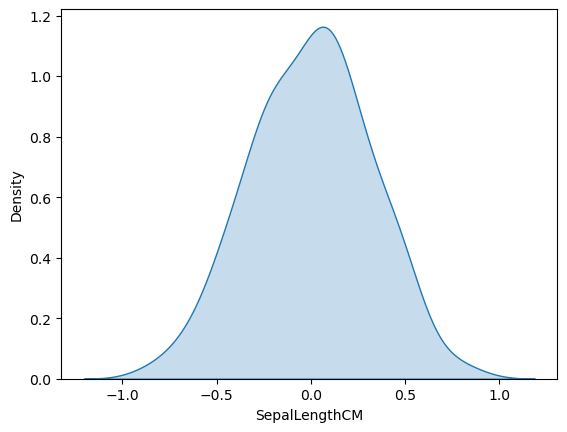

In [36]:
sns.kdeplot(residuals, fill=True)

<Axes: xlabel='SepalLengthCM', ylabel='Density'>

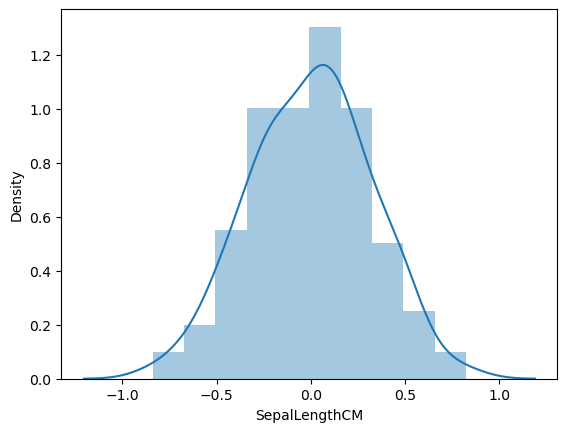

In [37]:
sns.distplot(residuals)

<Axes: xlabel='SepalLengthCM', ylabel='Count'>

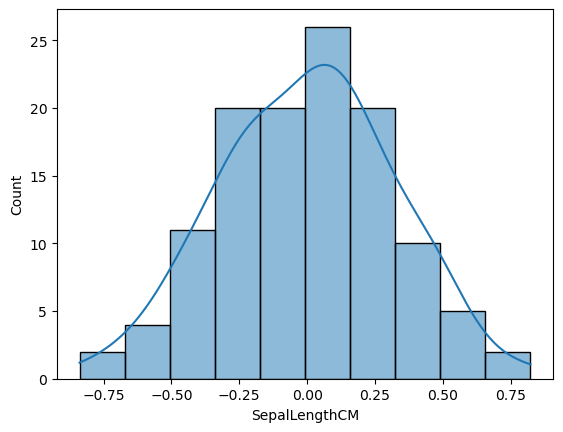

In [38]:
sns.histplot(residuals, kde=True)

<Axes: ylabel='Density'>

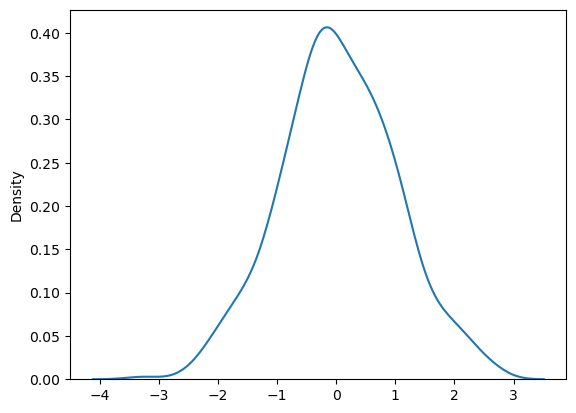

In [39]:
arr1 = np.random.randn(500)
sns.kdeplot(arr1)

In [40]:
arr2 = np.array([1,2,2,42,45,49,45,42,43,50,51,50,54,46,47,52,43,53,56,40,49,55,51,52,54,49,53])
arr3 = np.array([1,2,5,4,6,3,4,8,7,9,10,5,4,1,0,3,9,8,5,4,10,8,7,6,6,0,1,2,4,5,6,51,52,53])

<Axes: ylabel='Density'>

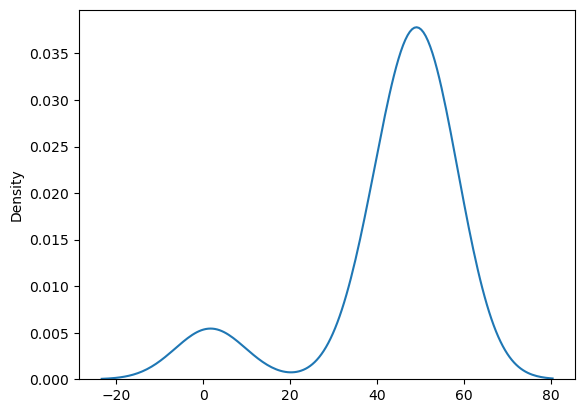

In [41]:
sns.kdeplot(arr2)

<Axes: ylabel='Density'>

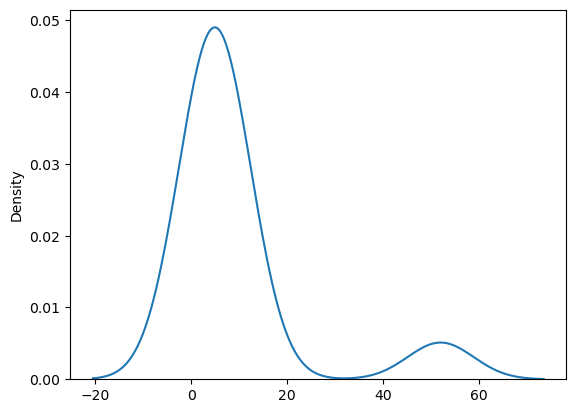

In [42]:
sns.kdeplot(arr3)

### 2. QQ-Plot

In [ ]:
Quantile-Quantile plot

In [43]:
import statsmodels.api as sm

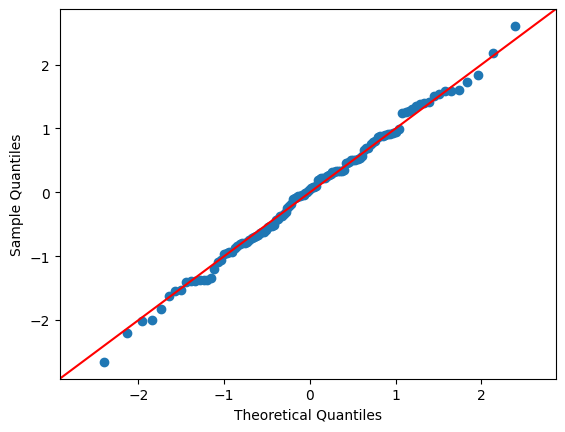

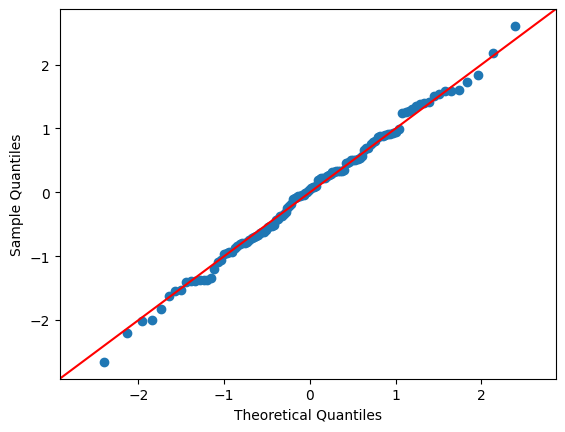

In [59]:
sm.qqplot(residuals, line='45', fit=True)

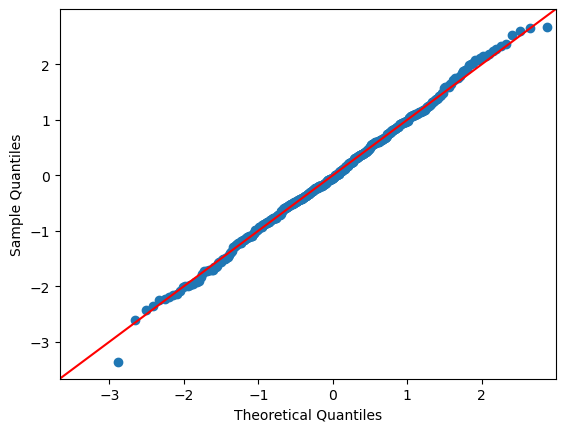

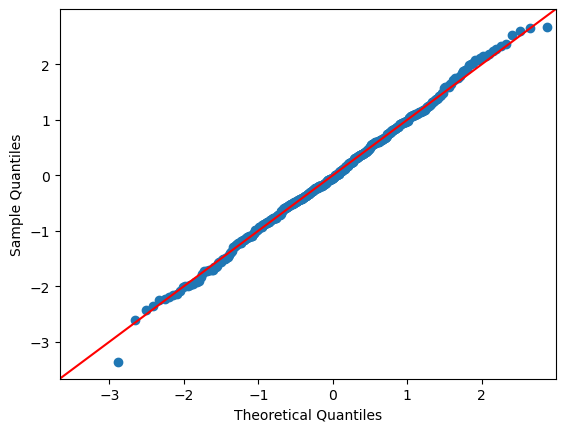

In [44]:
sm.qqplot(arr1, line='45', fit=True)

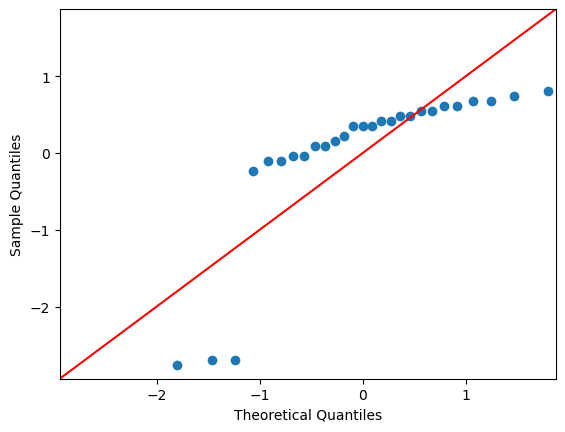

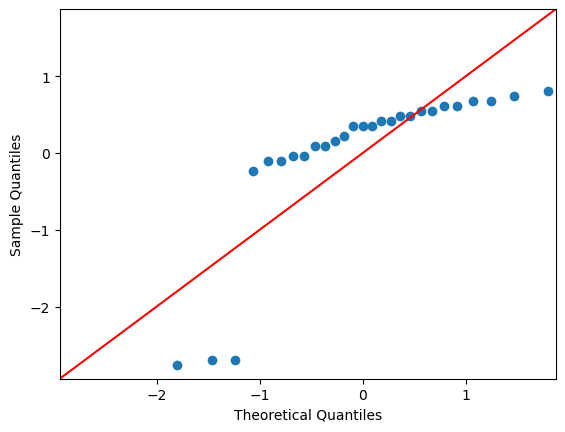

In [45]:
sm.qqplot(arr2, line='45', fit=True)

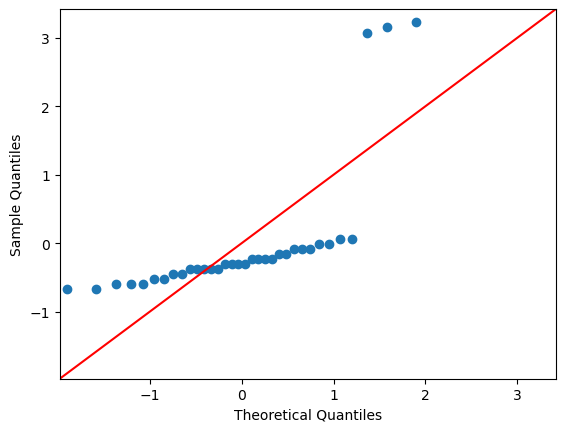

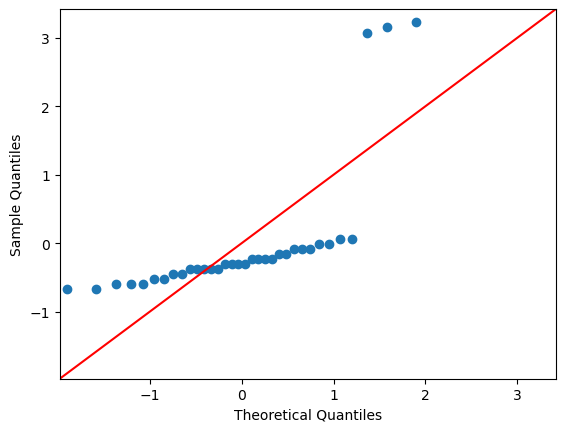

In [46]:
sm.qqplot(arr3, line='45', fit=True)

### 3. Skewness

In [ ]:
Normally Distributed/Symmetrical Data >> Bell Curve Shape
Positive Skewness >> Tail of the distribution is longer towards right hand side
Negative Skewness >> Tail of the distribution is longer towards left hand side

-0.5 to +0.5      >> Symmetrical Distribution (-0.2, 0.4, 0.3)
0.5 to 1          >> Positive Skewed data (0.6,0.7,0.9)
-0.5 to -1        >> Negative Skewed data (-0.6,-0.7,-0.9)

skew > 1  >> Highly Positively skewed data (1.45,2.3,3)
skew < -1 >> Highly Negatively skewed data (-1.45,-2.3,-3)

Positively skewed data >> Mean > Median > Mode
Negatively skewed data >> Mode > Median > Mean

<Axes: xlabel='SepalLengthCM', ylabel='Density'>

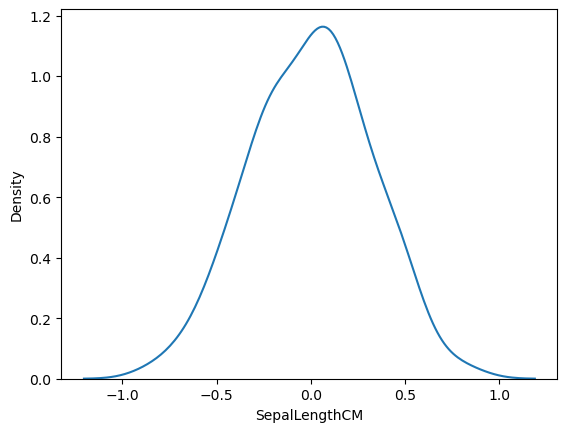

In [47]:
sns.kdeplot(residuals)

In [48]:
residuals.skew()

-0.06487225410579311

In [49]:
Mean = residuals.mean()
print('Mean :', np.around(Mean, 2))

Median = residuals.median()
print('Median :', np.around(Median, 2))

Mode = residuals.mode()[0]
print('Mode :', np.around(Mode, 2))

Mean : 0.0
Median : 0.02
Mode : -0.3


In [50]:
s2 = pd.Series(arr2)
s3 = pd.Series(arr3)

<Axes: ylabel='Density'>

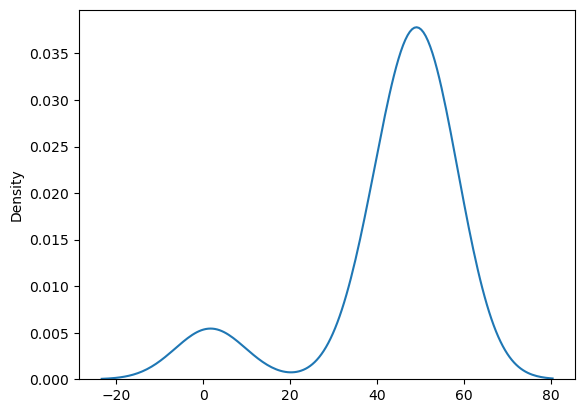

In [51]:
sns.kdeplot(s2)

In [52]:
s2.skew()

-2.253533754588781

In [53]:
Mean = s2.mean()
print('Mean :', np.around(Mean, 2))

Median = s2.median()
print('Median :', np.around(Median, 2))

Mode = s2.mode()[0]
print('Mode :', np.around(Mode, 2))

Mean : 43.56
Median : 49.0
Mode : 49


<Axes: ylabel='Density'>

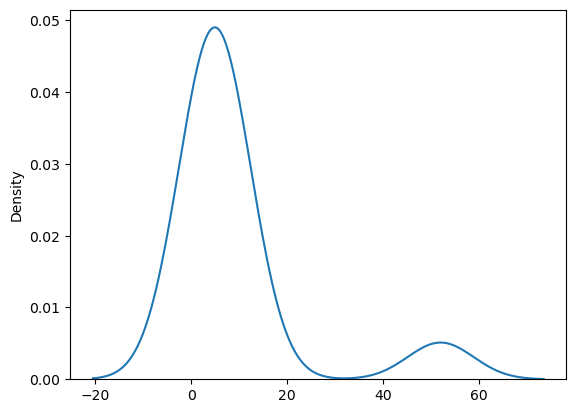

In [54]:
sns.kdeplot(s3)

In [55]:
s3.skew()

2.8244646329569356

In [56]:
Mean = s3.mean()
print('Mean :', np.around(Mean, 2))

Median = s3.median()
print('Median :', np.around(Median, 2))

Mode = s3.mode()[0]
print('Mode :', np.around(Mode, 2))

Mean : 9.09
Median : 5.0
Mode : 4


### Hypothesis Testing

In [ ]:
Hypothesis >> An Assumption

Null Hypothesis (H0) : Data is Normally distributed
    Null Hypothesis is True
    We are accepting Null Hypothesis

Alternate Hypothesis (Ha) : Data is not Normally distributed
    Alternate is False
    We are rejecting the Alternate Hypothesis

p_val >> 0 to 1
Significance Level >> 0.05

p_val >= 0.05  : Null Hypothesis is True  >> We are accepting H0
p_val < 0.05   : Null Hypothesis is False >> We are rejecting H0
                 Alternate Hypothesis is True >> We are accepting Ha

p_val >= 0.05 >> Data is normally distributed
p_val < 0.05 >> Data is not normally distributed

In [ ]:
Hypothesis Testing to Check Normality:
    1. shapiro
    2. kstest
    3. normal test

### 1. shapiro

In [59]:
from scipy.stats import shapiro, kstest, normaltest

<Axes: xlabel='SepatlWidthCM', ylabel='Density'>

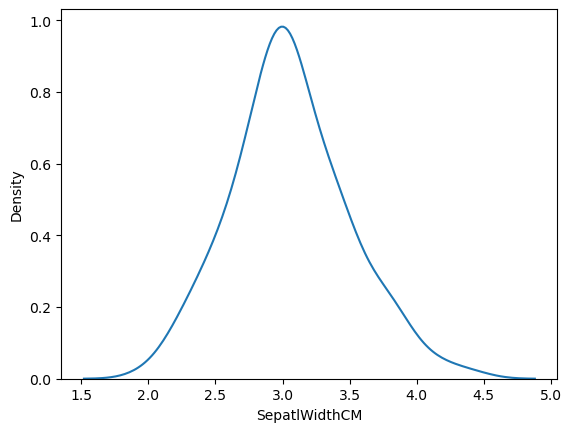

In [57]:
sns.kdeplot(iris_df['SepatlWidthCM'])

In [60]:
shapiro(iris_df['SepatlWidthCM'])

ShapiroResult(statistic=0.9849168062210083, pvalue=0.10112646222114563)

In [61]:
stat, p_val = shapiro(iris_df['SepatlWidthCM'])
print('P-Value :', p_val)

significance_level = 0.05

if p_val >= significance_level:
    print('Null Hypothesis is True')
    print('Data is Normally Distributed')

else:
    print('Null Hypothesis is False')
    print('Alternate Hypothesis is True')
    print('Data is not Normally Distributed')

P-Value : 0.10112646222114563
Null Hypothesis is True
Data is Normally Distributed


<Axes: xlabel='SepalLengthCM', ylabel='Density'>

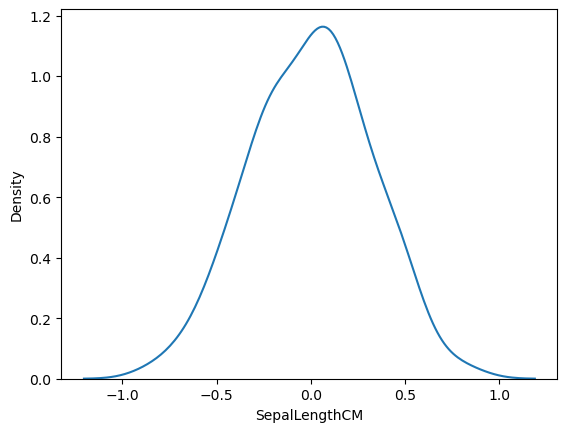

In [62]:
sns.kdeplot(residuals)

In [63]:
stat, p_val = shapiro(residuals)
print('P-Value :', p_val)

significance_level = 0.05

if p_val >= significance_level:
    print('Null Hypothesis is True')
    print('Data is Normally Distributed')

else:
    print('Null Hypothesis is False')
    print('Alternate Hypothesis is True')
    print('Data is not Normally Distributed')

P-Value : 0.9722458124160767
Null Hypothesis is True
Data is Normally Distributed


In [64]:
stat, p_val = shapiro(s2)
print('P-Value :', round(p_val, 10))

significance_level = 0.05

if p_val >= significance_level:
    print('Null Hypothesis is True')
    print('Data is Normally Distributed')

else:
    print('Null Hypothesis is False')
    print('Alternate Hypothesis is True')
    print('Data is not Normally Distributed')

P-Value : 4.554e-07
Null Hypothesis is False
Alternate Hypothesis is True
Data is not Normally Distributed


In [65]:
stat, p_val = shapiro(s3)
print('P-Value :', round(p_val, 10))

significance_level = 0.05

if p_val >= significance_level:
    print('Null Hypothesis is True')
    print('Data is Normally Distributed')

else:
    print('Null Hypothesis is False')
    print('Alternate Hypothesis is True')
    print('Data is not Normally Distributed')

P-Value : 1.8e-09
Null Hypothesis is False
Alternate Hypothesis is True
Data is not Normally Distributed


### 2. kstest

In [ ]:
Kolmogorov-Smirnov test

In [66]:
stat, p_val = kstest(residuals, 'norm')
print('P-Value :', round(p_val, 10))

significance_level = 0.05

if p_val >= significance_level:
    print('Null Hypothesis is True')
    print('Data is Normally Distributed')

else:
    print('Null Hypothesis is False')
    print('Alternate Hypothesis is True')
    print('Data is not Normally Distributed')

P-Value : 1.94e-08
Null Hypothesis is False
Alternate Hypothesis is True
Data is not Normally Distributed


In [67]:
stat, p_val = kstest(s2, 'norm')
print('P-Value :', round(p_val, 10))

significance_level = 0.05

if p_val >= significance_level:
    print('Null Hypothesis is True')
    print('Data is Normally Distributed')

else:
    print('Null Hypothesis is False')
    print('Alternate Hypothesis is True')
    print('Data is not Normally Distributed')

P-Value : 0.0
Null Hypothesis is False
Alternate Hypothesis is True
Data is not Normally Distributed


In [69]:
stat, p_val = kstest(arr1, 'norm')
print('P-Value :', round(p_val, 10))

significance_level = 0.05

if p_val >= significance_level:
    print('Null Hypothesis is True')
    print('Data is Normally Distributed')

else:
    print('Null Hypothesis is False')
    print('Alternate Hypothesis is True')
    print('Data is not Normally Distributed')

P-Value : 0.458157037
Null Hypothesis is True
Data is Normally Distributed


### 3. normal test

In [ ]:
Test whether a sample differs from a normal distribution.

This function tests the null hypothesis that a sample comes
from a normal distribution.  It is based on D'Agostino and
Pearson's [1]_, [2]_ test that combines skew and kurtosis to
produce an omnibus test of normality.

In [70]:
stat, p_val = normaltest(residuals)
print('P-Value :', round(p_val, 10))

significance_level = 0.05

if p_val >= significance_level:
    print('Null Hypothesis is True')
    print('Data is Normally Distributed')

else:
    print('Null Hypothesis is False')
    print('Alternate Hypothesis is True')
    print('Data is not Normally Distributed')

P-Value : 0.8597049946
Null Hypothesis is True
Data is Normally Distributed


In [71]:
stat, p_val = normaltest(s2)
print('P-Value :', round(p_val, 10))

significance_level = 0.05

if p_val >= significance_level:
    print('Null Hypothesis is True')
    print('Data is Normally Distributed')

else:
    print('Null Hypothesis is False')
    print('Alternate Hypothesis is True')
    print('Data is not Normally Distributed')

P-Value : 8.8945e-06
Null Hypothesis is False
Alternate Hypothesis is True
Data is not Normally Distributed


### 4. Homoscedasticity

In [ ]:
Homoscedasticity >> No Heteroscedaticity

1. Assumption of equal variance
2. Homoscedasticity >> Constant error/residuals
3. Constant error >> Constant deviation from zero
4. Dependent var vs residuals

In [72]:
y_train

126    6.2
23     5.1
64     5.6
117    7.7
84     5.4
      ... 
75     6.6
43     5.0
22     4.6
72     6.3
15     5.7
Name: SepalLengthCM, Length: 120, dtype: float64

<Axes: xlabel='SepalLengthCM', ylabel='SepalLengthCM'>

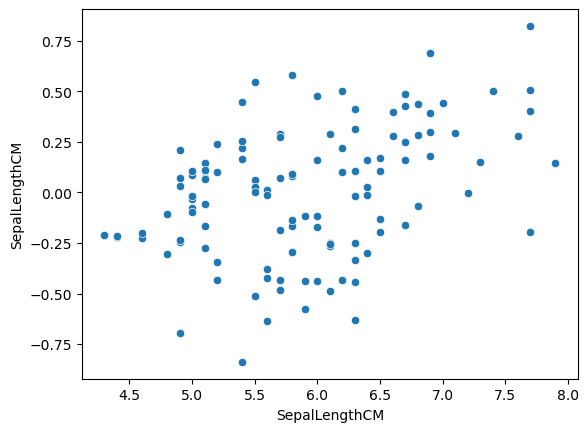

In [73]:
sns.scatterplot(x = y_train, y= residuals)

In [74]:
df2 = pd.DataFrame()
df2['Actual'] = y_train
df2['Residuals'] = residuals
df2['Flag'] = np.where(df2['Residuals'] >= 0, 'pos','neg')
df2

,Actual,Residuals,Flag
126,6.2,0.218690,pos
23,5.1,0.103351,pos
64,5.6,0.013164,pos
117,7.7,-0.196913,neg
84,5.4,-0.838169,neg
...,...,...,...
75,6.6,0.396472,pos
43,5.0,-0.019109,neg
22,4.6,-0.200936,neg
72,6.3,0.104897,pos


<Axes: xlabel='SepalLengthCM', ylabel='SepalLengthCM'>

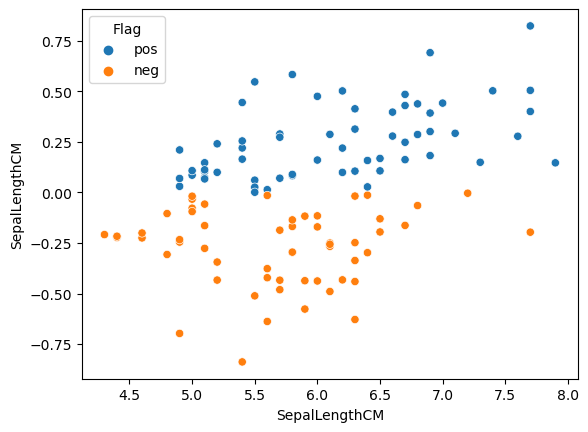

In [75]:
sns.scatterplot(x = y_train, y= residuals, hue = df2['Flag'])

In [76]:
pos = df2[df2['Flag']=='pos']
pos['Residuals'].sum()

15.316292622147449

In [77]:
neg = df2[df2['Flag']=='neg']
neg['Residuals'].sum()

-15.316292622147355

In [79]:
np.around(neg['Residuals'].sum() + pos['Residuals'].sum(), 5)

0.0

### Testing on User Inputs

In [ ]:
Testing on single row

In [80]:
x_test[3:4]

,SepatlWidthCM,PetalLengthCM,PetalWidthCM,Species
12,3.0,1.4,0.1,0


In [81]:
y_test[3:4]

12    4.8
Name: SepalLengthCM, dtype: float64

In [82]:
linear_reg.predict(x_test[3:4])

array([4.72931905])

In [55]:
x_test.columns

Index(['SepatlWidthCM', 'PetalLengthCM', 'PetalWidthCM', 'Species'], dtype='object')

In [83]:
x_test.head(1).T

,6
SepatlWidthCM,3.4
PetalLengthCM,1.4
PetalWidthCM,0.3
Species,0.0


In [88]:
SepatlWidthCM = 3.4
PetalLengthCM = 1.4
PetalWidthCM = 0.3
Species = 0.0

# Target (SepalLengthCM) = ?

test_array = np.array([SepatlWidthCM, PetalLengthCM, PetalWidthCM, Species], ndmin = 2)
test_array

predicted_value = linear_reg.predict(test_array)[0]
print('Predicted Value is :', np.around(predicted_value, 3))

Predicted Value is : 4.921


In [89]:
SepatlWidthCM = 3.4
PetalLengthCM = 1.4
PetalWidthCM = 0.3
Species = 0.0

# Target (SepalLengthCM) = ?

test_array = np.array([SepatlWidthCM, PetalLengthCM, PetalWidthCM, Species], ndmin = 2)
test_array

def get_predicted_value(test):
    predicted_value = linear_reg.predict(test)[0]
    print('Predicted Value is :', round(predicted_value, 3))
                        
get_predicted_value(test_array)

Predicted Value is : 4.921


### Storing ML Algorithm/Instance

In [90]:
import pickle
import joblib

In [91]:
with open('Linear_Reg_Model.pkl', 'wb') as f:
    pickle.dump(linear_reg, f)

In [92]:
linear_reg.coef_

array([ 0.67427277,  0.73517612, -0.38876303, -0.22592787])

In [93]:
linear_reg.intercept_

1.7161304636997787

### OLS by statesmodels

In [ ]:
LinearRegression()    >> by sklearn
LinearRegression()    >> by statsmodels

OLS >> helps in identifying more significant features, that can influence our target

In [94]:
import statsmodels.api as sm

In [96]:
x = iris_df.drop('SepalLengthCM',axis=1)     # 2D
y = iris_df['SepalLengthCM']   # 1D

x = sm.add_constant(x)
x

,const,SepatlWidthCM,PetalLengthCM,PetalWidthCM,Species
0,1.0,3.5,1.4,0.2,0
1,1.0,3.0,1.4,0.2,0
2,1.0,3.2,1.3,0.2,0
3,1.0,3.1,1.5,0.2,0
4,1.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,1.0,3.0,5.2,2.3,2
146,1.0,2.5,5.0,1.9,2
147,1.0,3.0,5.2,2.0,2
148,1.0,3.4,5.4,2.3,2


In [72]:
x['const'].unique()

array([1.])

### Train Test Split

In [97]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.20, random_state=2)
x_train

,const,SepatlWidthCM,PetalLengthCM,PetalWidthCM,Species
126,1.0,2.8,4.8,1.8,2
23,1.0,3.3,1.7,0.5,0
64,1.0,2.9,3.6,1.3,1
117,1.0,3.8,6.7,2.2,2
84,1.0,3.0,4.5,1.5,1
...,...,...,...,...,...
75,1.0,3.0,4.4,1.4,1
43,1.0,3.5,1.6,0.6,0
22,1.0,3.6,1.0,0.2,0
72,1.0,2.5,4.9,1.5,1


In [98]:
lr_model = sm.OLS(y_train, x_train)
linear_reg_ols = lr_model.fit()
linear_reg_ols

In [99]:
print(linear_reg_ols.summary())

                            OLS Regression Results                            
Dep. Variable:          SepalLengthCM   R-squared:                       0.848
Model:                            OLS   Adj. R-squared:                  0.843
Method:                 Least Squares   F-statistic:                     160.6
Date:                Mon, 14 Jul 2025   Prob (F-statistic):           4.28e-46
Time:                        08:26:07   Log-Likelihood:                -31.899
No. Observations:                 120   AIC:                             73.80
Df Residuals:                     115   BIC:                             87.74
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             1.7161      0.290      5.916

In [ ]:
H0 >> There is no linear relation between ind var and dependent var
p_val < 0.05 >> reject H0

In [ ]:
https://medium.com/swlh/interpreting-linear-regression-through-statsmodels-summary-4796d359035a